# SOP return forecasting — fixed, audit-ready notebook

This notebook rebuilds the SOP replication and extensions with the requested fixes:

- one full-panel historical-mean benchmark, reused everywhere;
- no look-ahead in strategy variance estimates;
- matched-sample A/B/C/D portfolio comparison with `N`, start date, and end date;
- forecast-evaluation metrics kept separate from portfolio metrics;
- clean Goyal-Welch predictor list with non-real-time, duplicate, and outcome-like variables removed;
- standardized crisis windows;
- VIX-enhanced SOP comparisons on a common sample;
- robustness checks for one-month-lagged fundamentals/VIX, winsorized `ge`/`gm`, and alternative training windows;
- descriptive-statistics formatting that does not multiply `count`, `skew`, or `kurt` by 100.

The public FRED key is kept as a fallback, while `FRED_API_KEY` can still override it from the environment.

In [1]:
# ============================================================
# 0. User settings
# ============================================================

from pathlib import Path
import os

EXCEL_PATH = "agoyal_data.xlsx"
OUTPUT_DIR = "."
OUTPUT_SUFFIX = ""
TARGET_END = "2024-12-31"

# Public fallback key retained by request. Environment variable takes precedence.
PUBLIC_FRED_API_KEY = "99b6b648410a405f7a66d8117889ea0e"
FRED_API_KEY = os.getenv("FRED_API_KEY", PUBLIC_FRED_API_KEY)

USE_FRED_EXTENSION = True
USE_SHILLER_EXTENSION = True
USE_LOCAL_CACHE_FIRST = True
REQUEST_TIMEOUT_SECONDS = 10

FORECAST_START = "1948-01-31"
MIN_TRAIN_MONTHS = 240
SHRINKAGE_INTENSITY = 1200

ROLLING_VAR_WINDOW = 60
GAMMA_MARKOWITZ = 2.0
WEIGHT_BOUNDS = (0.0, 1.5)
VM_SCALE_BOUNDS = (0.25, 4.0)

CRISIS_WINDOWS = {
    "Dot-com": ("2000-03-31", "2002-09-30"),
    "GFC": ("2007-10-31", "2009-03-31"),
    "COVID": ("2020-02-29", "2020-04-30"),
    "Inflation shock": ("2022-01-31", "2022-10-31"),
}

BASE_DIR = Path.cwd()
if not (BASE_DIR / EXCEL_PATH).exists() and Path("/mnt/data/agoyal_data.xlsx").exists():
    BASE_DIR = Path("/mnt/data")

OUT = BASE_DIR / OUTPUT_DIR
OUT.mkdir(parents=True, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Goyal workbook: {BASE_DIR / EXCEL_PATH}")
print(f"Output directory: {OUT}")
print(f"Target end: {TARGET_END}")
print(f"Forecast start: {FORECAST_START}")
print(f"FRED extension: {USE_FRED_EXTENSION}; Shiller extension: {USE_SHILLER_EXTENSION}; local cache first: {USE_LOCAL_CACHE_FIRST}")

Base directory: /Users/lucas/Documents/SOP
Goyal workbook: /Users/lucas/Documents/SOP/agoyal_data.xlsx
Output directory: /Users/lucas/Documents/SOP
Target end: 2024-12-31
Forecast start: 1948-01-31
FRED extension: True; Shiller extension: True; local cache first: True


In [2]:
# ============================================================
# 1. Imports
# ============================================================

import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import requests
except Exception:
    requests = None

try:
    from scipy import stats
except Exception:
    stats = None

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.6f}".format

In [3]:
# ============================================================
# 2. Utility functions
# ============================================================

def clean_columns(cols):
    return [str(c).strip().lower() for c in cols]


def month_end(s):
    return pd.to_datetime(s, errors="coerce").dt.to_period("M").dt.to_timestamp("M")


def infer_monthly_date_column(frame):
    out = frame.copy()
    out.columns = clean_columns(out.columns)
    if "date" not in out.columns:
        for c in ["yyyymm", "month", "mdate", "ym"]:
            if c in out.columns:
                out = out.rename(columns={c: "date"})
                break
    if "date" not in out.columns:
        raise KeyError("No date/yyyymm-like column found.")
    s = out["date"]
    if pd.api.types.is_numeric_dtype(s):
        sn = pd.to_numeric(s, errors="coerce")
        si = sn.round().astype("Int64")
        nn = si.dropna()
        if len(nn) and nn.between(180001, 220012).mean() > 0.80:
            parsed = pd.to_datetime(si.astype(str), format="%Y%m", errors="coerce")
        elif len(nn) and nn.between(1, 60000).mean() > 0.80:
            parsed = pd.to_datetime(sn, unit="D", origin="1899-12-30", errors="coerce")
        else:
            parsed = pd.to_datetime(s.astype(str), errors="coerce")
    else:
        parsed = pd.to_datetime(s, errors="coerce")
    out["date"] = parsed.dt.to_period("M").dt.to_timestamp("M")
    return out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)


def infer_annual_date_column(frame):
    out = frame.copy()
    out.columns = clean_columns(out.columns)
    if "year" not in out.columns:
        for c in ["yyyy", "date", "yr"]:
            if c in out.columns:
                out = out.rename(columns={c: "year"})
                break
    if "year" not in out.columns:
        raise KeyError("No year/yyyy-like column found.")
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    return out.dropna(subset=["year"]).sort_values("year").reset_index(drop=True)


def safe_log(x):
    x = pd.to_numeric(x, errors="coerce")
    return pd.Series(np.where(x > 0, np.log(x), np.nan), index=x.index)


def safe_log1p(x):
    x = pd.to_numeric(x, errors="coerce")
    return pd.Series(np.where(x > -1, np.log1p(x), np.nan), index=x.index)


def winsorize(s, lower=0.01, upper=0.99):
    s = pd.to_numeric(s, errors="coerce").copy()
    lo, hi = s.quantile([lower, upper])
    return s.clip(lo, hi)


def compound_simple_return(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return (1 + x).prod() - 1 if len(x) else np.nan


def max_drawdown(returns):
    r = pd.Series(returns).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    peak = wealth.cummax()
    return (wealth / peak - 1).min()


def add_suffix(name):
    p = Path(name)
    return p.with_name(f"{p.stem}{OUTPUT_SUFFIX}{p.suffix}")

In [4]:
# ============================================================
# 3. Forecasting and inference helpers
# ============================================================

def forecast_metrics(frame, forecast_col, y_col="ret_lead", benchmark_col="hist_mean", model_name=None):
    needed = [y_col, forecast_col, benchmark_col, "forecast_target_date"]
    use = frame[needed].dropna().copy()
    if len(use) == 0:
        return {
            "model": model_name or forecast_col,
            "N": 0,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
            "MSE": np.nan,
            "MSE_benchmark": np.nan,
            "OOS_R2_vs_HM": np.nan,
            "MAE": np.nan,
            "MAE_benchmark": np.nan,
            "MAE_gain": np.nan,
            "MSE_F": np.nan,
        }
    err = use[y_col] - use[forecast_col]
    berr = use[y_col] - use[benchmark_col]
    mse = (err ** 2).mean()
    bmse = (berr ** 2).mean()
    mae = err.abs().mean()
    bmae = berr.abs().mean()
    return {
        "model": model_name or forecast_col,
        "N": int(len(use)),
        "start_date": use["forecast_target_date"].min(),
        "end_date": use["forecast_target_date"].max(),
        "MSE": mse,
        "MSE_benchmark": bmse,
        "OOS_R2_vs_HM": 1 - mse / bmse if bmse > 0 else np.nan,
        "MAE": mae,
        "MAE_benchmark": bmae,
        "MAE_gain": bmae - mae,
        "MSE_F": len(use) * (bmse - mse) / mse if mse > 0 else np.nan,
    }


def connor_shrunk_univariate(frame, y_col, x_col, min_train=240, intensity=1200, start_idx=1):
    y = pd.to_numeric(frame[y_col], errors="coerce").reset_index(drop=True)
    x = pd.to_numeric(frame[x_col], errors="coerce").reset_index(drop=True)
    pred = pd.Series(np.nan, index=frame.index, dtype=float)
    for i in range(start_idx, len(frame)):
        if pd.isna(x.iat[i]):
            continue
        mask = x.iloc[:i].notna() & y.iloc[:i].notna()
        n = int(mask.sum())
        if n < min_train:
            continue
        xtr = x.iloc[:i][mask].to_numpy(dtype=float)
        ytr = y.iloc[:i][mask].to_numpy(dtype=float)
        if np.nanstd(xtr) < 1e-14:
            pred.iat[i] = np.nanmean(ytr)
            continue
        X = np.column_stack([np.ones(n), xtr])
        beta = np.linalg.lstsq(X, ytr, rcond=None)[0]
        b_hat = beta[1]
        b_star = (n / (n + intensity)) * b_hat
        a_star = ytr.mean() - b_star * xtr.mean()
        pred.iat[i] = a_star + b_star * float(x.iat[i])
    return pred


def hac_se_mean(x, max_lag=None):
    x = pd.Series(x).dropna().to_numpy(dtype=float)
    n = len(x)
    if n < 3:
        return np.nan
    z = x - x.mean()
    if max_lag is None:
        max_lag = int(np.floor(4 * (n / 100) ** (2 / 9)))
    gamma0 = np.dot(z, z) / n
    var = gamma0
    for lag in range(1, max_lag + 1):
        cov = np.dot(z[lag:], z[:-lag]) / n
        weight = 1 - lag / (max_lag + 1)
        var += 2 * weight * cov
    return np.sqrt(max(var, 0) / n)


def dm_loss_test(frame, model_col, benchmark_model_col, y_col="ret_lead"):
    use = frame[[y_col, model_col, benchmark_model_col]].dropna()
    if len(use) < 5:
        return {
            "comparison": f"{model_col} vs {benchmark_model_col}",
            "N": int(len(use)),
            "mean_loss_diff": np.nan,
            "t_stat": np.nan,
            "p_value": np.nan,
        }
    loss_model = (use[y_col] - use[model_col]) ** 2
    loss_benchmark = (use[y_col] - use[benchmark_model_col]) ** 2
    d = loss_benchmark - loss_model
    se = hac_se_mean(d)
    t = d.mean() / se if se and se > 0 else np.nan
    p = 2 * (1 - stats.t.cdf(abs(t), df=len(use) - 1)) if stats is not None and pd.notna(t) else np.nan
    return {
        "comparison": f"{model_col} vs {benchmark_model_col}",
        "N": int(len(use)),
        "mean_loss_diff": d.mean(),
        "t_stat": t,
        "p_value": p,
    }

## Data loading

The panel starts from the Goyal-Welch workbook. FRED columns are merged from the cached enriched file when available, then downloaded only if the cache is missing. Shiller extension code is retained for cases where the Goyal file does not reach the requested target date; in this uploaded dataset, Goyal already reaches 2024-12.

In [5]:
# ============================================================
# 4. External-data loaders and cache merger
# ============================================================

FRED_SPECS = {
    "SP500": {"series_id": "SP500", "frequency": "m", "aggregation_method": "eop"},
    "CPIAUCSL": {"series_id": "CPIAUCSL", "frequency": "m", "aggregation_method": "avg"},
    "TB3MS": {"series_id": "TB3MS", "frequency": "m", "aggregation_method": "avg"},
    "VIXCLS": {"series_id": "VIXCLS", "frequency": "m", "aggregation_method": "eop"},
    "USREC": {"series_id": "USREC"},
}


def fred_observations(series_id, observation_start=None, observation_end=None, frequency=None, aggregation_method=None):
    if not USE_FRED_EXTENSION or not FRED_API_KEY or requests is None:
        return pd.DataFrame(columns=["date", series_id])
    params = {"series_id": series_id, "api_key": FRED_API_KEY, "file_type": "json"}
    if observation_start is not None:
        params["observation_start"] = pd.Timestamp(observation_start).date().isoformat()
    if observation_end is not None:
        params["observation_end"] = pd.Timestamp(observation_end).date().isoformat()
    if frequency is not None:
        params["frequency"] = frequency
    if aggregation_method is not None:
        params["aggregation_method"] = aggregation_method
    try:
        r = requests.get(
            "https://api.stlouisfed.org/fred/series/observations",
            params=params,
            timeout=REQUEST_TIMEOUT_SECONDS,
        )
        r.raise_for_status()
        payload = r.json().get("observations", [])
        if not payload:
            return pd.DataFrame(columns=["date", series_id])
        out = pd.DataFrame(payload)
        out["date"] = month_end(out["date"])
        out[series_id] = pd.to_numeric(out["value"].replace(".", np.nan), errors="coerce")
        return out[["date", series_id]].drop_duplicates("date")
    except Exception as exc:
        print(f"FRED download skipped/failed for {series_id}: {exc}")
        return pd.DataFrame(columns=["date", series_id])


def fetch_fred_bundle(start, end, missing_cols):
    frames = []
    for col in missing_cols:
        spec = FRED_SPECS[col]
        f = fred_observations(
            spec["series_id"],
            observation_start=start,
            observation_end=end,
            frequency=spec.get("frequency"),
            aggregation_method=spec.get("aggregation_method"),
        )
        if not f.empty:
            f = f.rename(columns={spec["series_id"]: col})
            frames.append(f)
    if not frames:
        return pd.DataFrame(columns=["date"] + missing_cols)
    out = frames[0]
    for f in frames[1:]:
        out = out.merge(f, on="date", how="outer")
    return out.sort_values("date").reset_index(drop=True)


def merge_fred_cache_or_download(monthly):
    out = monthly.copy()
    external_cols = list(FRED_SPECS.keys())
    source_rows = []

    cache_path = BASE_DIR / "sop_monthly_enriched.csv"
    if USE_LOCAL_CACHE_FIRST and cache_path.exists():
        cache = pd.read_csv(cache_path, parse_dates=["date"])
        cache["date"] = month_end(cache["date"])
        cached_cols = [c for c in external_cols if c in cache.columns]
        if cached_cols:
            out = out.merge(cache[["date"] + cached_cols].drop_duplicates("date"), on="date", how="left")
            for c in cached_cols:
                source_rows.append({"variable": c, "source": "FRED cached in sop_monthly_enriched.csv", "non_null": int(out[c].notna().sum())})

    missing_cols = [c for c in external_cols if c not in out.columns or out[c].notna().sum() == 0]
    if missing_cols:
        fred = fetch_fred_bundle(out["date"].min(), max(out["date"].max(), pd.Timestamp(TARGET_END)), missing_cols)
        if not fred.empty:
            out = out.merge(fred, on="date", how="left", suffixes=("", "_fred_dl"))
            for c in missing_cols:
                dl = f"{c}_fred_dl"
                if dl in out.columns:
                    out[c] = out[c].combine_first(out[dl]) if c in out.columns else out[dl]
                    out = out.drop(columns=[dl])
                source_rows.append({"variable": c, "source": "FRED API", "non_null": int(out[c].notna().sum())})

    for c in external_cols:
        if c not in out.columns:
            out[c] = np.nan
            source_rows.append({"variable": c, "source": "missing", "non_null": 0})

    if "USREC" in out.columns:
        out["USREC"] = pd.to_numeric(out["USREC"], errors="coerce").fillna(0).astype(int)

    return out, pd.DataFrame(source_rows).drop_duplicates(["variable", "source"], keep="last")


def load_shiller_monthly_if_needed(current_end):
    if not USE_SHILLER_EXTENSION or pd.Timestamp(current_end) >= pd.Timestamp(TARGET_END):
        return pd.DataFrame()
    local_candidates = [BASE_DIR / "IE Data.xls", BASE_DIR / "ie_data.xls", BASE_DIR / "ie_data.xlsx", BASE_DIR / "ie_data.csv"]
    urls = [
        "http://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/7fd201b2-28ad-476c-bc67-7a2cab5304a3/ie_data.xls?ver=1775144929611",
        "https://www.econ.yale.edu/~shiller/data/ie_data.csv",
        "https://www.econ.yale.edu/~shiller/data/ie_data.xlsx",
    ]
    sources = [p for p in local_candidates if p.exists()] + urls
    for src in sources:
        try:
            if str(src).lower().endswith(".csv"):
                raw = pd.read_csv(src, skiprows=7)
            else:
                raw = pd.read_excel(src, skiprows=7)
            cols = clean_columns(raw.columns)
            raw.columns = cols
            date_col = cols[0]
            out = raw.rename(columns={date_col: "date"}).copy()
            out["date"] = pd.to_numeric(out["date"], errors="coerce")
            out = out.dropna(subset=["date"])
            years = np.floor(out["date"]).astype(int)
            months = ((out["date"] - years) * 100).round().astype(int)
            months = months.clip(1, 12)
            out["date"] = pd.to_datetime(dict(year=years, month=months, day=1)).dt.to_period("M").dt.to_timestamp("M")
            rename = {}
            for c in out.columns:
                lc = str(c).lower()
                if lc in ["p", "price"]:
                    rename[c] = "price_shiller"
                elif lc in ["d", "dividend"]:
                    rename[c] = "dividend_shiller"
                elif lc in ["e", "earnings"]:
                    rename[c] = "earnings_shiller"
            out = out.rename(columns=rename)
            keep = ["date"] + [c for c in ["price_shiller", "dividend_shiller", "earnings_shiller"] if c in out.columns]
            return out[keep].drop_duplicates("date").sort_values("date")
        except Exception as exc:
            print(f"Shiller source skipped/failed ({src}): {exc}")
    return pd.DataFrame()

In [6]:
# ============================================================
# 5. Load Goyal-Welch workbook and build source audit
# ============================================================

excel_path = BASE_DIR / EXCEL_PATH
if not excel_path.exists():
    raise FileNotFoundError(f"Could not find {excel_path}.")

monthly_raw = infer_monthly_date_column(pd.read_excel(excel_path, sheet_name="Monthly"))
annual_raw = infer_annual_date_column(pd.read_excel(excel_path, sheet_name="Annual"))

for raw in [monthly_raw, annual_raw]:
    if "price" not in raw.columns and "index" in raw.columns:
        raw.rename(columns={"index": "price"}, inplace=True)

rename_map = {"d/p": "dp_gw", "d/y": "dy", "e/p": "ep", "d/e": "de", "b/m": "bm", "i/k": "ik"}
monthly_raw = monthly_raw.rename(columns=rename_map)
annual_raw = annual_raw.rename(columns=rename_map)

required = ["date", "price", "d12", "e12", "ret"]
missing = [c for c in required if c not in monthly_raw.columns]
if missing:
    raise KeyError(f"Missing required Goyal columns: {missing}")

clean_predictors = ["dfy", "tbl", "tms", "ntis", "infl", "ltr", "dfr", "svar", "dp_gw", "dy", "ep", "de", "bm", "cay"]
base_cols = ["date", "price", "d12", "e12", "ret", "retx", "rfree", "lty"] + clean_predictors
monthly = monthly_raw[[c for c in base_cols if c in monthly_raw.columns]].copy()
for c in monthly.columns:
    if c != "date":
        monthly[c] = pd.to_numeric(monthly[c], errors="coerce")

monthly, fred_source_audit = merge_fred_cache_or_download(monthly)
shiller_extra = load_shiller_monthly_if_needed(monthly["date"].max())

source_audit = pd.DataFrame([
    {"variable": "price, d12, e12, ret, retx, rfree, Goyal predictors", "source": "Amit Goyal-Welch workbook", "non_null": len(monthly)},
    {"variable": "Shiller price/dividend/earnings extension", "source": "Robert Shiller data", "non_null": int(len(shiller_extra))},
])
source_audit = pd.concat([source_audit, fred_source_audit], ignore_index=True)
source_audit.to_csv(OUT / add_suffix("sop_data_source_audit.csv"), index=False)

display(source_audit)
print(f"Monthly Goyal rows: {len(monthly_raw):,} from {monthly_raw['date'].min().date()} to {monthly_raw['date'].max().date()}")
print(f"Annual Goyal rows:  {len(annual_raw):,} from {int(annual_raw['year'].min())} to {int(annual_raw['year'].max())}")

,variable,source,non_null
0,"price, d12, e12, ret, retx, rfree, Goyal predi...",Amit Goyal-Welch workbook,1848
1,Shiller price/dividend/earnings extension,Robert Shiller data,0
2,SP500,FRED API,104
3,CPIAUCSL,FRED API,936
4,TB3MS,FRED API,1092
5,VIXCLS,FRED API,420
6,USREC,FRED API,1848


Monthly Goyal rows: 1,848 from 1871-01-31 to 2024-12-31
Annual Goyal rows:  154 from 1871 to 2024


## SOP components and single benchmark construction

The historical mean is computed once on the full monthly panel as the expanding mean of realized log returns through date `t`. It is never recomputed inside VIX, crisis, or strategy subsets.

In [7]:
# ============================================================
# 6. Construct monthly SOP components and one full-panel historical mean
# ============================================================

df = monthly.sort_values("date").reset_index(drop=True).copy()

for c in ["price", "d12", "e12", "ret", "rfree", "tbl"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Goyal ret and rfree are monthly simple returns in decimal form.
df["ret_decimal"] = df["ret"]
df["r_log"] = safe_log1p(df["ret_decimal"])
df["rf_simple"] = pd.to_numeric(df.get("rfree"), errors="coerce") if "rfree" in df.columns else np.nan

if "tbl" in df.columns:
    tbl = pd.to_numeric(df["tbl"], errors="coerce")
    df["rf_forecast_simple"] = (tbl / 12).where(tbl.abs() < 1, tbl / 1200)
else:
    df["rf_forecast_simple"] = df["rf_simple"]

pe = df["price"] / df["e12"].replace(0, np.nan)
df["dp"] = safe_log1p(df["d12"] / (12 * df["price"]))
df["ge"] = safe_log(df["e12"] / df["e12"].shift(1))
df["gm"] = safe_log(pe / pe.shift(1))
df["gs"] = df["ge"].rolling(MIN_TRAIN_MONTHS, min_periods=MIN_TRAIN_MONTHS).mean()
df["ms"] = df["gs"] + df["dp"]

# Forecast timing: row t forecast predicts row t+1 return.
df["forecast_target_date"] = df["date"].shift(-1)
df["ret_lead"] = df["r_log"].shift(-1)
df["rf_log"] = safe_log1p(df["rf_simple"])
df["rf_log_next"] = df["rf_log"].shift(-1)
df["rf_simple_next"] = df["rf_simple"].shift(-1)
df["xret_lead"] = df["ret_lead"] - df["rf_log_next"]

# Fixed once on the full panel, then reused everywhere.
df["hist_mean"] = df["r_log"].expanding(min_periods=MIN_TRAIN_MONTHS).mean()
df["hist_mean_xret"] = (df["r_log"] - df["rf_log"]).expanding(min_periods=MIN_TRAIN_MONTHS).mean()

# Robustness: one-month-lagged fundamentals.
df["d12_lag1"] = df["d12"].shift(1)
df["e12_lag1"] = df["e12"].shift(1)
pe_lagfund = df["price"] / df["e12_lag1"].replace(0, np.nan)
df["dp_lagfund"] = safe_log1p(df["d12_lag1"] / (12 * df["price"]))
df["ge_lagfund"] = safe_log(df["e12_lag1"] / df["e12_lag1"].shift(1))
df["gm_lagfund"] = safe_log(pe_lagfund / pe_lagfund.shift(1))
df["gs_lagfund"] = df["ge_lagfund"].rolling(MIN_TRAIN_MONTHS, min_periods=MIN_TRAIN_MONTHS).mean()
df["ms_lagfund"] = df["gs_lagfund"] + df["dp_lagfund"]

# Robustness: winsorized ge/gm.
df["ge_winsor"] = winsorize(df["ge"], 0.01, 0.99)
df["gm_winsor"] = winsorize(df["gm"], 0.01, 0.99)
df["gs_winsor"] = df["ge_winsor"].rolling(MIN_TRAIN_MONTHS, min_periods=MIN_TRAIN_MONTHS).mean()
df["ms_winsor"] = df["gs_winsor"] + df["dp"]

if "VIXCLS" in df.columns:
    df["VIXCLS_lag1"] = df["VIXCLS"].shift(1)
else:
    df["VIXCLS"] = np.nan
    df["VIXCLS_lag1"] = np.nan

component_sum = df["dp"] + df["ge"] + df["gm"]
df["decomp_error"] = df["r_log"] - component_sum

monthly_path = OUT / add_suffix("sop_monthly_enriched.csv")
df.to_csv(monthly_path, index=False)

hist_check = df.loc[df["hist_mean"].notna(), ["date", "hist_mean"]].head()
print(f"Saved monthly fixed panel: {monthly_path}")
print(f"Monthly panel shape: {df.shape}")
print(f"First non-null full-panel historical means:")
display(hist_check)

Saved monthly fixed panel: /Users/lucas/Documents/SOP/sop_monthly_enriched.csv
Monthly panel shape: (1848, 57)
First non-null full-panel historical means:


,date,hist_mean
899,1945-12-31,0.005102
900,1946-01-31,0.005360
901,1946-02-28,0.005059
902,1946-03-31,0.005235
903,1946-04-30,0.005358


In [8]:
# ============================================================
# 7. Descriptive stats with correct presentation scaling
# ============================================================

stat_vars = ["r_log", "dp", "ge", "gm", "gs", "ms", "hist_mean", "VIXCLS", "dfy", "ntis", "tbl", "tms"]
stat_vars = [v for v in stat_vars if v in df.columns]

stats_rows = []
for v in stat_vars:
    s = pd.to_numeric(df[v], errors="coerce").dropna()
    stats_rows.append({
        "variable": v,
        "count": int(s.count()),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "p25": s.quantile(0.25),
        "median": s.median(),
        "p75": s.quantile(0.75),
        "max": s.max(),
        "skew": s.skew(),
        "kurt": s.kurt(),
    })

desc_stats = pd.DataFrame(stats_rows)
desc_stats.to_csv(OUT / add_suffix("sop_descriptive_stats.csv"), index=False)
display(desc_stats)

,variable,count,mean,std,min,p25,median,p75,max,skew,kurt
0,r_log,1188,0.008152,0.053676,-0.338921,-0.016972,0.013076,0.038189,0.346643,-0.481913,7.663306
1,dp,1848,0.003526,0.001471,0.000904,0.002510,0.003504,0.004438,0.012721,0.570889,1.307467
2,ge,1847,0.003392,0.036848,-0.528281,-0.008757,0.005479,0.016208,0.703855,1.904543,114.377726
3,gm,1847,0.000501,0.057400,-0.723815,-0.025612,0.000906,0.028071,0.536072,-0.531330,23.861632
4,gs,1608,0.003443,0.002673,-0.005382,0.001704,0.004039,0.005421,0.008672,-0.649149,-0.288059
5,ms,1608,0.006800,0.002561,-0.002787,0.005522,0.006903,0.008395,0.014329,-0.294076,0.410407
6,hist_mean,949,0.007441,0.000904,0.004118,0.007207,0.007716,0.007952,0.008779,-1.878417,3.593005
7,VIXCLS,420,19.538905,7.503524,9.510000,13.757500,17.665000,23.505000,59.890000,1.708700,4.471878
8,dfy,1272,0.011660,0.006834,0.003200,0.007100,0.009400,0.014100,0.056400,2.204194,7.515247
9,ntis,1177,0.015331,0.025841,-0.055954,0.002195,0.015588,0.026702,0.177041,1.613389,7.725082


## Forecast evaluation

These tables evaluate forecasts only. Portfolio returns are handled later in a separate section.

In [9]:
# ============================================================
# 8. Baseline SOP and annual non-overlapping evaluation
# ============================================================

eval_base = df[df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()

baseline_table = pd.DataFrame([
    forecast_metrics(eval_base, "ms", model_name="Baseline SOP"),
    forecast_metrics(eval_base, "ms_lagfund", model_name="SOP with lagged D12/E12"),
    forecast_metrics(eval_base, "ms_winsor", model_name="SOP with winsorized ge/gm"),
])
baseline_table.to_csv(OUT / add_suffix("sop_baseline_forecast_performance.csv"), index=False)

display(baseline_table)

valid_months = eval_base[["forecast_target_date", "ret_lead", "ms", "hist_mean"]].dropna().copy()
valid_months["target_year"] = valid_months["forecast_target_date"].dt.year
annual_rows = []
for year, g in valid_months.groupby("target_year"):
    if len(g) == 12:
        annual_rows.append({
            "year": int(year),
            "start_date": g["forecast_target_date"].min(),
            "forecast_target_date": g["forecast_target_date"].max(),
            "r_log_ann": g["ret_lead"].sum(),
            "ms_ann": g["ms"].sum(),
            "hist_mean_ann": g["hist_mean"].sum(),
            "N_months": int(len(g)),
        })
annual_eval = pd.DataFrame(annual_rows)
annual_metrics = forecast_metrics(
    annual_eval.rename(columns={"r_log_ann": "ret_lead", "ms_ann": "ms", "hist_mean_ann": "hist_mean"}),
    "ms",
    model_name="Baseline SOP annual non-overlap",
)
annual_table = pd.DataFrame([annual_metrics])
annual_eval.to_csv(OUT / add_suffix("sop_annual_nonoverlap.csv"), index=False)
annual_table.to_csv(OUT / add_suffix("sop_annual_forecast_performance.csv"), index=False)

display(annual_table)

,model,N,start_date,end_date,MSE,MSE_benchmark,OOS_R2_vs_HM,MAE,MAE_benchmark,MAE_gain,MSE_F
0,Baseline SOP,924,1948-01-31,2024-12-31,0.001771,0.001781,0.005767,0.032137,0.032162,0.000025,5.359241
1,SOP with lagged D12/E12,924,1948-01-31,2024-12-31,0.001772,0.001781,0.005063,0.032150,0.032162,0.000013,4.702264
2,SOP with winsorized ge/gm,924,1948-01-31,2024-12-31,0.001769,0.001781,0.006847,0.032117,0.032162,0.000046,6.369965


,model,N,start_date,end_date,MSE,MSE_benchmark,OOS_R2_vs_HM,MAE,MAE_benchmark,MAE_gain,MSE_F
0,Baseline SOP annual non-overlap,77,1948-12-31,2024-12-31,0.025845,0.026547,0.026420,0.130686,0.130986,0.000300,2.089566


In [10]:
# ============================================================
# 9. Clean Goyal-Welch benchmark predictor comparison
# ============================================================

# Excludes USREC/non-real-time variables, FRED duplicates, outcome variables (ret/retx), and short specialized add-ons.
BENCHMARK_PREDICTORS = ["dfy", "tbl", "tms", "ntis", "infl", "ltr", "dfr", "svar", "dp_gw", "dy", "ep", "de", "bm"]
BENCHMARK_PREDICTORS = [p for p in BENCHMARK_PREDICTORS if p in df.columns]

bench_df = df.copy()
for p in BENCHMARK_PREDICTORS:
    bench_df[f"fc_{p}"] = connor_shrunk_univariate(bench_df, "ret_lead", p, MIN_TRAIN_MONTHS, SHRINKAGE_INTENSITY)

bench_rows = [forecast_metrics(bench_df[bench_df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)], "ms", model_name="SOP baseline")]
for p in BENCHMARK_PREDICTORS:
    bench_rows.append(forecast_metrics(
        bench_df[bench_df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)],
        f"fc_{p}",
        model_name=p,
    ))

bench_table = pd.DataFrame(bench_rows).sort_values("OOS_R2_vs_HM", ascending=False).reset_index(drop=True)
bench_table.to_csv(OUT / add_suffix("sop_benchmark_results.csv"), index=False)

display(bench_table[["model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain", "MSE_F"]])

,model,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain,MSE_F
0,SOP baseline,924,1948-01-31,2024-12-31,0.005767,0.000025,5.359241
1,ep,924,1948-01-31,2024-12-31,0.002687,-0.000099,2.489425
2,dy,924,1948-01-31,2024-12-31,0.000456,-0.000179,0.421680
3,dp_gw,924,1948-01-31,2024-12-31,0.000421,-0.000112,0.388873
4,infl,924,1948-01-31,2024-12-31,0.000334,0.000026,0.308945
5,ntis,924,1948-01-31,2024-12-31,0.000241,0.000119,0.222829
6,bm,924,1948-01-31,2024-12-31,-0.000138,-0.000213,-0.127837
7,dfy,924,1948-01-31,2024-12-31,-0.000362,-0.000013,-0.334395
8,ltr,924,1948-01-31,2024-12-31,-0.000396,-0.000049,-0.365630
9,tms,924,1948-01-31,2024-12-31,-0.000636,0.000008,-0.587712


## VIX-enhanced SOP on a common sample

The VIX comparison is built on one common row set. Baseline SOP, VIX-enhanced SOP, DFY-enhanced SOP, and NTIS-enhanced SOP all use the same `ret_lead`, the same full-panel `hist_mean`, and the same dates.

In [11]:
# ============================================================
# 10. VIX-enhanced multiple-growth forecasts on common sample
# ============================================================

vix_df = bench_df.copy()
vix_df["gm_lead"] = vix_df["gm"].shift(-1)

VIX_COMPARE = ["VIXCLS", "dfy", "ntis", "tbl", "tms"]
VIX_COMPARE = [p for p in VIX_COMPARE if p in vix_df.columns]

for p in VIX_COMPARE:
    vix_df[f"gm_fc_{p}"] = connor_shrunk_univariate(vix_df, "gm_lead", p, MIN_TRAIN_MONTHS, SHRINKAGE_INTENSITY)
    vix_df[f"ms_enh_{p}"] = vix_df["gs"] + vix_df["dp"] + vix_df[f"gm_fc_{p}"]

vix_df["gm_fc_VIX_lag1"] = connor_shrunk_univariate(vix_df, "gm_lead", "VIXCLS_lag1", MIN_TRAIN_MONTHS, SHRINKAGE_INTENSITY)
vix_df["ms_enh_VIX_lag1"] = vix_df["gs"] + vix_df["dp"] + vix_df["gm_fc_VIX_lag1"]

common_required = ["ret_lead", "hist_mean", "ms", "forecast_target_date"] + [
    f"ms_enh_{p}" for p in ["VIXCLS", "dfy", "ntis"] if f"ms_enh_{p}" in vix_df.columns
]
vix_common = vix_df[vix_df["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=common_required).copy()

vix_rows = [forecast_metrics(vix_common, "ms", model_name="Baseline SOP")]
for p in VIX_COMPARE:
    col = f"ms_enh_{p}"
    if col in vix_common.columns:
        m = forecast_metrics(vix_common, col, model_name=f"Enhanced SOP: {p}")
        mse_model = ((vix_common["ret_lead"] - vix_common[col]) ** 2).mean()
        mse_base = ((vix_common["ret_lead"] - vix_common["ms"]) ** 2).mean()
        m["R2_vs_baseline_SOP"] = 1 - mse_model / mse_base if mse_base > 0 else np.nan
        vix_rows.append(m)

vix_common_table = pd.DataFrame(vix_rows).sort_values("OOS_R2_vs_HM", ascending=False).reset_index(drop=True)
vix_common_table.to_csv(OUT / add_suffix("sop_vix_common_results.csv"), index=False)
vix_df.to_csv(OUT / add_suffix("sop_vix_common_forecasts.csv"), index=False)

display(vix_common_table[["model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "R2_vs_baseline_SOP", "MAE_gain"]])
print(f"Common VIX comparison sample: N={len(vix_common)}, {vix_common['forecast_target_date'].min().date()} to {vix_common['forecast_target_date'].max().date()}")

,model,N,start_date,end_date,OOS_R2_vs_HM,R2_vs_baseline_SOP,MAE_gain
0,Enhanced SOP: VIXCLS,179,2010-02-28,2024-12-31,0.013373,0.022818,-0.000076
1,Enhanced SOP: ntis,179,2010-02-28,2024-12-31,0.001160,0.010722,0.000327
2,Enhanced SOP: tms,179,2010-02-28,2024-12-31,-0.005061,0.004561,-0.000036
3,Enhanced SOP: dfy,179,2010-02-28,2024-12-31,-0.008223,0.001429,-0.000408
4,Enhanced SOP: tbl,179,2010-02-28,2024-12-31,-0.008233,0.001419,-0.000163
5,Baseline SOP,179,2010-02-28,2024-12-31,-0.009666,NaN,-0.000225


Common VIX comparison sample: N=179, 2010-02-28 to 2024-12-31


In [12]:
# ============================================================
# 11. VIX versus Goyal enhanced-forecast loss-difference tests
# ============================================================

dm_rows = []
if "ms_enh_VIXCLS" in vix_common.columns:
    for p in ["dfy", "ntis", "tbl", "tms"]:
        col = f"ms_enh_{p}"
        if col in vix_common.columns:
            dm_rows.append(dm_loss_test(vix_common, "ms_enh_VIXCLS", col))

dm_table = pd.DataFrame(dm_rows)
dm_table.to_csv(OUT / add_suffix("sop_vix_dm_tests.csv"), index=False)
display(dm_table)

,comparison,N,mean_loss_diff,t_stat,p_value
0,ms_enh_VIXCLS vs ms_enh_dfy,179,0.000038,1.275812,0.203684
1,ms_enh_VIXCLS vs ms_enh_ntis,179,0.000022,0.719337,0.472877
2,ms_enh_VIXCLS vs ms_enh_tbl,179,0.000038,1.228887,0.220736
3,ms_enh_VIXCLS vs ms_enh_tms,179,0.000033,1.095132,0.274938


In [13]:
# ============================================================
# 12. Multiple-reversion extension: PE residual relative to predictor-implied fair value
# ============================================================

def two_stage_reversion_forecast(frame, level_col, predictor_col, target_col, min_train=240, intensity=1200):
    level = pd.to_numeric(frame[level_col], errors="coerce").reset_index(drop=True)
    predx = pd.to_numeric(frame[predictor_col], errors="coerce").reset_index(drop=True)
    target = pd.to_numeric(frame[target_col], errors="coerce").reset_index(drop=True)
    out = pd.Series(np.nan, index=frame.index, dtype=float)
    for i in range(1, len(frame)):
        m1 = level.iloc[:i].notna() & predx.iloc[:i].notna()
        if m1.sum() < min_train or pd.isna(predx.iat[i]) or pd.isna(level.iat[i]):
            continue
        x1 = predx.iloc[:i][m1].to_numpy(dtype=float)
        y1 = level.iloc[:i][m1].to_numpy(dtype=float)
        X1 = np.column_stack([np.ones(len(x1)), x1])
        b = np.linalg.lstsq(X1, y1, rcond=None)[0]
        fair_i = b[0] + b[1] * predx.iat[i]
        res_i = level.iat[i] - fair_i
        fair_prev = pd.Series(np.nan, index=range(i), dtype=float)
        fair_prev.loc[m1[m1].index] = b[0] + b[1] * predx.iloc[:i][m1]
        resid_prev = level.iloc[:i] - fair_prev
        m2 = resid_prev.notna() & target.iloc[:i].notna()
        if m2.sum() < min_train:
            continue
        x2 = resid_prev[m2].to_numpy(dtype=float)
        y2 = target.iloc[:i][m2].to_numpy(dtype=float)
        if np.std(x2) < 1e-14:
            out.iat[i] = np.nanmean(y2)
            continue
        X2 = np.column_stack([np.ones(len(x2)), x2])
        beta = np.linalg.lstsq(X2, y2, rcond=None)[0]
        slope = (len(x2) / (len(x2) + intensity)) * beta[1]
        intercept = y2.mean() - slope * x2.mean()
        out.iat[i] = intercept + slope * res_i
    return out

rev_df = vix_df.copy()
rev_df["pe_log"] = safe_log(rev_df["price"] / rev_df["e12"].replace(0, np.nan))

for p in ["VIXCLS", "dfy", "ntis"]:
    if p in rev_df.columns:
        rev_df[f"gm_rev_{p}"] = two_stage_reversion_forecast(rev_df, "pe_log", p, "gm_lead", MIN_TRAIN_MONTHS, SHRINKAGE_INTENSITY)
        rev_df[f"ms_rev_{p}"] = rev_df["gs"] + rev_df["dp"] + rev_df[f"gm_rev_{p}"]

rev_required = ["ret_lead", "hist_mean", "ms"] + [f"ms_rev_{p}" for p in ["VIXCLS", "dfy", "ntis"] if f"ms_rev_{p}" in rev_df.columns]
rev_common = rev_df[rev_df["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=rev_required).copy()

rev_rows = [forecast_metrics(rev_common, "ms", model_name="Baseline SOP")]
for p in ["VIXCLS", "dfy", "ntis"]:
    col = f"ms_rev_{p}"
    if col in rev_common.columns:
        rev_rows.append(forecast_metrics(rev_common, col, model_name=f"Reversion SOP: {p}"))

rev_table = pd.DataFrame(rev_rows).sort_values("OOS_R2_vs_HM", ascending=False).reset_index(drop=True)
rev_table.to_csv(OUT / add_suffix("sop_reversion_results.csv"), index=False)

display(rev_table[["model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain"]])

,model,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain
0,Reversion SOP: VIXCLS,179,2010-02-28,2024-12-31,0.002472,0.000032
1,Baseline SOP,179,2010-02-28,2024-12-31,-0.009666,-0.000225
2,Reversion SOP: dfy,179,2010-02-28,2024-12-31,-0.015967,-0.000444
3,Reversion SOP: ntis,179,2010-02-28,2024-12-31,-0.017863,-0.000512


## Crisis forecast performance

Fixed windows use forecast target months. The dynamic VIX rule is ex ante: a target month is reached from a forecast date whose month-end VIX is above 25.

In [14]:
# ============================================================
# 13. Standardized crisis windows and forecast performance
# ============================================================

def fixed_crisis_label(ts):
    if pd.isna(ts):
        return None
    for label, (start, end) in CRISIS_WINDOWS.items():
        if pd.Timestamp(start) <= ts <= pd.Timestamp(end):
            return label
    return None

crisis_df = vix_df.copy()
crisis_df["fixed_crisis"] = crisis_df["forecast_target_date"].apply(fixed_crisis_label)
crisis_df["is_fixed_crisis"] = crisis_df["fixed_crisis"].notna()
crisis_df["is_vix25"] = pd.to_numeric(crisis_df["VIXCLS"], errors="coerce") > 25

base_full = crisis_df[crisis_df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()
crisis_rows = []
for definition, flag in [("Fixed windows", "is_fixed_crisis"), ("VIX>25 at forecast date", "is_vix25")]:
    for regime, mask_value in [("Crisis", True), ("Non-crisis", False)]:
        sub = base_full[base_full[flag] == mask_value]
        met = forecast_metrics(sub, "ms", model_name="Baseline SOP")
        met.update({"definition": definition, "regime": regime})
        crisis_rows.append(met)

crisis_forecast_table = pd.DataFrame(crisis_rows)
crisis_forecast_table.to_csv(OUT / add_suffix("sop_crisis_forecast.csv"), index=False)

crisis_overlap = pd.crosstab(crisis_df["is_fixed_crisis"], crisis_df["is_vix25"], margins=True)
crisis_overlap.to_csv(OUT / add_suffix("sop_crisis_definition_overlap.csv"))

display(crisis_forecast_table[["definition", "regime", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain"]])
display(crisis_overlap)

,definition,regime,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain
0,Fixed windows,Crisis,62,2000-03-31,2022-10-31,0.030496,0.000754
1,Fixed windows,Non-crisis,862,1948-01-31,2024-12-31,0.000359,-0.000027
2,VIX>25 at forecast date,Crisis,79,1990-02-28,2022-11-30,-0.014450,-0.000797
3,VIX>25 at forecast date,Non-crisis,845,1948-01-31,2024-12-31,0.010392,0.000102


is_vix25,False,True,All
is_fixed_crisis,,,
False,1735,51,1786
True,34,28,62
All,1769,79,1848


## Portfolio evaluation

This section converts forecasts into trading strategies. It does not compute OOS R² on strategy returns. The 5-year variance estimate uses realized equity returns through date `t`, never `ret_lead`.

In [15]:
# ============================================================
# 14. Portfolio helpers and A/B/C/D strategy construction
# ============================================================

def markowitz_weight(forecast_log, rf_simple_forecast, variance, gamma=GAMMA_MARKOWITZ, lo=0.0, hi=1.5):
    exp_simple = np.expm1(forecast_log)
    excess = exp_simple - rf_simple_forecast
    w = excess / (gamma * variance)
    return w.clip(lo, hi)


def add_strategy(frame, forecast_col, prefix, vol_managed=False):
    w = markowitz_weight(frame[forecast_col], frame["rf_forecast_simple"], frame["rolling_var_5yr"])
    if vol_managed:
        w = (w * frame["vm_scale"]).clip(WEIGHT_BOUNDS[0], WEIGHT_BOUNDS[1])
    frame[f"w_{prefix}"] = w
    frame[f"ret_{prefix}"] = w * frame["equity_simple_next"] + (1 - w) * frame["rf_simple_next"]
    return frame


def strategy_metrics(frame, ret_col, weight_col=None, label=None):
    r = pd.to_numeric(frame[ret_col], errors="coerce").dropna()
    if len(r) == 0:
        return {"strategy": label or ret_col, "N": 0}
    sub = frame.loc[r.index]
    rf = pd.to_numeric(sub["rf_simple_next"], errors="coerce")
    ex = r - rf
    vol = r.std(ddof=1)
    return {
        "strategy": label or ret_col,
        "N": int(len(r)),
        "start_date": sub["forecast_target_date"].min(),
        "end_date": sub["forecast_target_date"].max(),
        "ann_return": (1 + r).prod() ** (12 / len(r)) - 1,
        "ann_vol": vol * np.sqrt(12),
        "ann_sharpe": ex.mean() / vol * np.sqrt(12) if vol and vol > 0 else np.nan,
        "cum_return": (1 + r).prod() - 1,
        "max_drawdown": max_drawdown(r),
        "avg_weight": pd.to_numeric(sub[weight_col], errors="coerce").mean() if weight_col else np.nan,
        "turnover": pd.to_numeric(sub[weight_col], errors="coerce").diff().abs().mean() if weight_col else np.nan,
        "CEQ_gamma3_ann": 12 * (ex.mean() - 0.5 * 3 * r.var(ddof=1)),
    }

port = vix_df.copy()
port["equity_simple_t"] = pd.to_numeric(port["ret_decimal"], errors="coerce")
port["equity_simple_next"] = port["equity_simple_t"].shift(-1)
port["rf_simple_next"] = port["rf_simple"].shift(-1)

# No look-ahead: this uses realized equity returns through date t.
port["rolling_var_5yr"] = port["equity_simple_t"].rolling(ROLLING_VAR_WINDOW, min_periods=ROLLING_VAR_WINDOW).var()

# Vol-management variance uses Goyal's stock variance if available, otherwise the same backward-looking monthly variance.
port["rv_t"] = pd.to_numeric(port["svar"], errors="coerce") if "svar" in port.columns else np.nan
port["rv_t"] = port["rv_t"].where(port["rv_t"] > 0, np.nan).fillna(port["rolling_var_5yr"])
port["rv_avg_expanding"] = port["rv_t"].expanding(min_periods=ROLLING_VAR_WINDOW).mean()
port["vm_scale"] = (port["rv_avg_expanding"] / port["rv_t"]).clip(VM_SCALE_BOUNDS[0], VM_SCALE_BOUNDS[1])

port = add_strategy(port, "ms", "A_SOP_Markowitz", vol_managed=False)
port = add_strategy(port, "ms", "B_SOP_VolManaged", vol_managed=True)
port = add_strategy(port, "ms_enh_VIXCLS", "C_VIX_Markowitz", vol_managed=False)
port = add_strategy(port, "ms_enh_VIXCLS", "D_VIX_VolManaged", vol_managed=True)

hm_w = markowitz_weight(port["hist_mean"], port["rf_forecast_simple"], port["rolling_var_5yr"])
port["w_HM_Markowitz"] = hm_w
port["ret_HM_Markowitz"] = hm_w * port["equity_simple_next"] + (1 - hm_w) * port["rf_simple_next"]
port["w_BuyHold"] = 1.0
port["ret_BuyHold"] = port["equity_simple_next"]

strategy_map = {
    "A: SOP + Markowitz": ("ret_A_SOP_Markowitz", "w_A_SOP_Markowitz"),
    "B: SOP + vol-managed": ("ret_B_SOP_VolManaged", "w_B_SOP_VolManaged"),
    "C: VIX-SOP + Markowitz": ("ret_C_VIX_Markowitz", "w_C_VIX_Markowitz"),
    "D: VIX-SOP + vol-managed": ("ret_D_VIX_VolManaged", "w_D_VIX_VolManaged"),
    "Historical mean + Markowitz": ("ret_HM_Markowitz", "w_HM_Markowitz"),
    "Buy-and-hold equity": ("ret_BuyHold", "w_BuyHold"),
}

abcd_return_cols = ["ret_A_SOP_Markowitz", "ret_B_SOP_VolManaged", "ret_C_VIX_Markowitz", "ret_D_VIX_VolManaged"]
abcd_weight_cols = [c.replace("ret_", "w_") for c in abcd_return_cols]
matched_required = ["forecast_target_date", "equity_simple_next", "rf_simple_next"] + abcd_return_cols + abcd_weight_cols
matched = port.dropna(subset=matched_required).copy()
matched = matched.dropna(subset=["ret_HM_Markowitz", "ret_BuyHold", "w_HM_Markowitz"])

strategy_table = pd.DataFrame([
    strategy_metrics(matched, ret_col, weight_col, label)
    for label, (ret_col, weight_col) in strategy_map.items()
])
strategy_table.to_csv(OUT / add_suffix("sop_strategy_matched_results.csv"), index=False)

matched_out_cols = ["date", "forecast_target_date"] + [v[0] for v in strategy_map.values()] + [v[1] for v in strategy_map.values()]
matched[matched_out_cols].to_csv(OUT / add_suffix("sop_abcd_returns_matched.csv"), index=False)

display(strategy_table[["strategy", "N", "start_date", "end_date", "ann_return", "ann_vol", "ann_sharpe", "max_drawdown", "avg_weight", "turnover", "CEQ_gamma3_ann"]])
print(f"Matched A/B/C/D sample: N={len(matched)}, {matched['forecast_target_date'].min().date()} to {matched['forecast_target_date'].max().date()}")

,strategy,N,start_date,end_date,ann_return,ann_vol,ann_sharpe,max_drawdown,avg_weight,turnover,CEQ_gamma3_ann
0,A: SOP + Markowitz,179,2010-02-28,2024-12-31,0.167717,0.199311,0.825797,-0.336373,1.316978,0.019605,0.105003
1,B: SOP + vol-managed,179,2010-02-28,2024-12-31,0.169494,0.167668,0.956178,-0.258638,1.282018,0.177937,0.118152
2,C: VIX-SOP + Markowitz,179,2010-02-28,2024-12-31,0.163638,0.201345,0.801267,-0.345327,1.185801,0.150990,0.100521
3,D: VIX-SOP + vol-managed,179,2010-02-28,2024-12-31,0.169052,0.168349,0.950481,-0.266018,1.211046,0.215017,0.117500
4,Historical mean + Markowitz,179,2010-02-28,2024-12-31,0.178740,0.201857,0.864785,-0.316754,1.347618,0.010070,0.113444
5,Buy-and-hold equity,179,2010-02-28,2024-12-31,0.143237,0.145685,0.918445,-0.236705,1.000000,0.000000,0.101967


Matched A/B/C/D sample: N=179, 2010-02-28 to 2024-12-31


In [16]:
# ============================================================
# 15. Crisis-window portfolio outcomes on the same matched sample
# ============================================================

matched["fixed_crisis"] = matched["forecast_target_date"].apply(fixed_crisis_label)
matched["is_vix25"] = pd.to_numeric(matched["VIXCLS"], errors="coerce") > 25

crisis_port_rows = []
for crisis_name in list(CRISIS_WINDOWS.keys()) + ["All fixed crisis months", "VIX>25 months"]:
    if crisis_name == "All fixed crisis months":
        sub = matched[matched["fixed_crisis"].notna()]
    elif crisis_name == "VIX>25 months":
        sub = matched[matched["is_vix25"]]
    else:
        sub = matched[matched["fixed_crisis"] == crisis_name]
    if len(sub) == 0:
        continue
    for label, (ret_col, weight_col) in strategy_map.items():
        met = strategy_metrics(sub, ret_col, weight_col, label)
        met.update({"crisis": crisis_name})
        crisis_port_rows.append(met)

crisis_portfolio_table = pd.DataFrame(crisis_port_rows)
crisis_portfolio_table.to_csv(OUT / add_suffix("sop_crisis_portfolio_outcomes.csv"), index=False)

display(crisis_portfolio_table[["crisis", "strategy", "N", "cum_return", "max_drawdown", "ann_sharpe", "avg_weight"]])

,crisis,strategy,N,cum_return,max_drawdown,ann_sharpe,avg_weight
0,COVID,A: SOP + Markowitz,3,-0.145985,-0.183596,-0.661865,1.500000
1,COVID,B: SOP + vol-managed,3,-0.168692,-0.095382,-2.166321,0.886322
2,COVID,C: VIX-SOP + Markowitz,3,-0.145985,-0.183596,-0.661865,1.500000
3,COVID,D: VIX-SOP + vol-managed,3,-0.168692,-0.095382,-2.166321,0.886322
4,COVID,Historical mean + Markowitz,3,-0.145985,-0.183596,-0.661865,1.500000
5,COVID,Buy-and-hold equity,3,-0.089980,-0.121997,-0.662987,1.000000
6,Inflation shock,A: SOP + Markowitz,10,-0.272503,-0.287358,-0.992726,1.457521
7,Inflation shock,B: SOP + vol-managed,10,-0.220874,-0.195601,-1.518070,0.938254
8,Inflation shock,C: VIX-SOP + Markowitz,10,-0.267275,-0.296973,-0.907959,1.500000
9,Inflation shock,D: VIX-SOP + vol-managed,10,-0.219898,-0.203609,-1.416852,0.963452


In [17]:
# ============================================================
# 16. Sharpe-difference and CEQ-gain tables on matched sample
# ============================================================

def sharpe_diff_test(frame, strategy_ret, benchmark_ret):
    use = frame[[strategy_ret, benchmark_ret, "rf_simple_next"]].dropna().copy()
    if len(use) < 12:
        return {"comparison": f"{strategy_ret} vs {benchmark_ret}", "N": len(use), "sharpe_diff": np.nan, "t_stat": np.nan, "p_value": np.nan}
    a = use[strategy_ret] - use["rf_simple_next"]
    b = use[benchmark_ret] - use["rf_simple_next"]
    diff = a - b
    se = hac_se_mean(diff)
    t = diff.mean() / se if se and se > 0 else np.nan
    p = 2 * (1 - stats.t.cdf(abs(t), df=len(use) - 1)) if stats is not None and pd.notna(t) else np.nan
    sr_a = a.mean() / use[strategy_ret].std(ddof=1) * np.sqrt(12)
    sr_b = b.mean() / use[benchmark_ret].std(ddof=1) * np.sqrt(12)
    return {"comparison": f"{strategy_ret} vs {benchmark_ret}", "N": int(len(use)), "sharpe_strategy": sr_a, "sharpe_benchmark": sr_b, "sharpe_diff": sr_a - sr_b, "mean_excess_diff_monthly": diff.mean(), "t_stat": t, "p_value": p}

sharpe_tests = pd.DataFrame([
    sharpe_diff_test(matched, "ret_B_SOP_VolManaged", "ret_A_SOP_Markowitz"),
    sharpe_diff_test(matched, "ret_C_VIX_Markowitz", "ret_A_SOP_Markowitz"),
    sharpe_diff_test(matched, "ret_D_VIX_VolManaged", "ret_A_SOP_Markowitz"),
    sharpe_diff_test(matched, "ret_A_SOP_Markowitz", "ret_HM_Markowitz"),
])
sharpe_tests.to_csv(OUT / add_suffix("sop_sharpe_tests_matched.csv"), index=False)

ceq = strategy_table[["strategy", "CEQ_gamma3_ann"]].copy()
base_ceq = ceq.loc[ceq["strategy"] == "A: SOP + Markowitz", "CEQ_gamma3_ann"].iloc[0]
hm_ceq = ceq.loc[ceq["strategy"] == "Historical mean + Markowitz", "CEQ_gamma3_ann"].iloc[0]
ceq["CEQ_gain_vs_A_ann"] = ceq["CEQ_gamma3_ann"] - base_ceq
ceq["CEQ_gain_vs_HM_ann"] = ceq["CEQ_gamma3_ann"] - hm_ceq
ceq.to_csv(OUT / add_suffix("sop_ceq_gain_matched.csv"), index=False)

display(sharpe_tests)
display(ceq)

,comparison,N,sharpe_strategy,sharpe_benchmark,sharpe_diff,mean_excess_diff_monthly,t_stat,p_value
0,ret_B_SOP_VolManaged vs ret_A_SOP_Markowitz,179,0.956178,0.825797,0.130381,-0.000356,-0.271403,0.786396
1,ret_C_VIX_Markowitz vs ret_A_SOP_Markowitz,179,0.801267,0.825797,-0.024530,-0.000272,-0.259926,0.795222
2,ret_D_VIX_VolManaged vs ret_A_SOP_Markowitz,179,0.950481,0.825797,0.124684,-0.000381,-0.297722,0.766262
3,ret_A_SOP_Markowitz vs ret_HM_Markowitz,179,0.825797,0.864785,-0.038988,-0.000831,-1.627368,0.105428


,strategy,CEQ_gamma3_ann,CEQ_gain_vs_A_ann,CEQ_gain_vs_HM_ann
0,A: SOP + Markowitz,0.105003,0.000000,-0.008441
1,B: SOP + vol-managed,0.118152,0.013148,0.004708
2,C: VIX-SOP + Markowitz,0.100521,-0.004482,-0.012922
3,D: VIX-SOP + vol-managed,0.117500,0.012497,0.004057
4,Historical mean + Markowitz,0.113444,0.008441,0.000000
5,Buy-and-hold equity,0.101967,-0.003036,-0.011476


## Robustness checks

In [18]:
# ============================================================
# 17. Robustness: training windows, lagged fundamentals/VIX, winsorized ge/gm
# ============================================================

robust_rows = []
for min_train in [60, 120, 180, 240, 300]:
    temp = df.copy()
    temp["gs_train"] = temp["ge"].rolling(min_train, min_periods=min_train).mean()
    temp["ms_train"] = temp["gs_train"] + temp["dp"]
    temp["hist_train"] = temp["r_log"].expanding(min_periods=min_train).mean()
    sub = temp[temp["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()
    met = forecast_metrics(sub, "ms_train", benchmark_col="hist_train", model_name=f"Baseline SOP train={min_train}")
    met["robustness"] = "training_window"
    robust_rows.append(met)

    temp["gm_lead"] = temp["gm"].shift(-1)
    temp["gm_fc_vix"] = connor_shrunk_univariate(temp, "gm_lead", "VIXCLS", min_train, SHRINKAGE_INTENSITY)
    temp["ms_vix_train"] = temp["gs_train"] + temp["dp"] + temp["gm_fc_vix"]
    common_temp = temp[temp["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=["ret_lead", "hist_train", "ms_train", "ms_vix_train"])
    met2 = forecast_metrics(common_temp, "ms_vix_train", benchmark_col="hist_train", model_name=f"VIX-enhanced SOP train={min_train}")
    met2["robustness"] = "vix_training_window"
    robust_rows.append(met2)

met = forecast_metrics(eval_base, "ms_lagfund", model_name="Lag D12/E12 by 1m")
met["robustness"] = "lagged_fundamentals"
robust_rows.append(met)

met = forecast_metrics(eval_base, "ms_winsor", model_name="Winsorize ge/gm 1-99%")
met["robustness"] = "winsorized_components"
robust_rows.append(met)

sub = vix_df[vix_df["forecast_target_date"] >= pd.Timestamp("1990-01-31")].dropna(subset=["ret_lead", "hist_mean", "ms_enh_VIX_lag1", "ms_enh_VIXCLS"])
met = forecast_metrics(sub, "ms_enh_VIX_lag1", model_name="VIX-enhanced with VIX lagged 1m")
met["robustness"] = "lagged_vix"
robust_rows.append(met)

robustness_table = pd.DataFrame(robust_rows)
robustness_table.to_csv(OUT / add_suffix("sop_robustness.csv"), index=False)

display(robustness_table[["robustness", "model", "N", "start_date", "end_date", "OOS_R2_vs_HM", "MAE_gain"]])

,robustness,model,N,start_date,end_date,OOS_R2_vs_HM,MAE_gain
0,training_window,Baseline SOP train=60,924,1948-01-31,2024-12-31,-0.021401,-0.000360
1,vix_training_window,VIX-enhanced SOP train=60,359,1995-02-28,2024-12-31,-0.027081,-0.000445
2,training_window,Baseline SOP train=120,924,1948-01-31,2024-12-31,0.001611,0.000030
3,vix_training_window,VIX-enhanced SOP train=120,299,2000-02-29,2024-12-31,-0.012218,-0.000106
4,training_window,Baseline SOP train=180,924,1948-01-31,2024-12-31,0.004845,0.000089
5,vix_training_window,VIX-enhanced SOP train=180,239,2005-02-28,2024-12-31,0.006918,0.000295
6,training_window,Baseline SOP train=240,924,1948-01-31,2024-12-31,0.005767,0.000025
7,vix_training_window,VIX-enhanced SOP train=240,179,2010-02-28,2024-12-31,0.013373,-0.000076
8,training_window,Baseline SOP train=300,888,1951-01-31,2024-12-31,0.002448,-0.000024
9,vix_training_window,VIX-enhanced SOP train=300,119,2015-02-28,2024-12-31,0.022953,0.000210


## Figures and last-12 forecast export

,date,forecast_target_date,ret_lead,hist_mean,ms,ms_enh_VIXCLS,ms_enh_dfy,ms_enh_ntis,ms_lagfund,ms_winsor
1836,2024-01-31,2024-02-29,0.051673,0.008048,0.006834,0.004525,0.005447,0.011144,0.006930,0.006467
1837,2024-02-29,2024-03-31,0.031703,0.008085,0.006680,0.003869,0.004895,0.010881,0.006774,0.006313
1838,2024-03-31,2024-04-30,-0.040614,0.008105,0.006552,0.003574,0.004800,0.010497,0.006645,0.006185
1839,2024-04-30,2024-05-31,0.048248,0.008063,0.006531,0.005220,0.004604,0.010445,0.006601,0.006164
1840,2024-05-31,2024-06-30,0.036524,0.008097,0.006409,0.003333,0.004393,0.010441,0.006477,0.006042
1841,2024-06-30,2024-07-31,0.012075,0.008121,0.006305,0.002986,0.004254,0.010620,0.006371,0.005938
1842,2024-07-31,2024-08-31,0.023993,0.008125,0.006291,0.005663,0.004435,0.010317,0.006293,0.005924
1843,2024-08-31,2024-09-30,0.022564,0.008138,0.006264,0.004746,0.004488,0.010210,0.006266,0.005898
1844,2024-09-30,2024-10-31,-0.008728,0.008150,0.006241,0.005937,0.004541,0.010110,0.006243,0.005874
1845,2024-10-31,2024-11-30,0.058665,0.008136,0.006308,0.010333,0.004203,0.010041,0.006251,0.005941


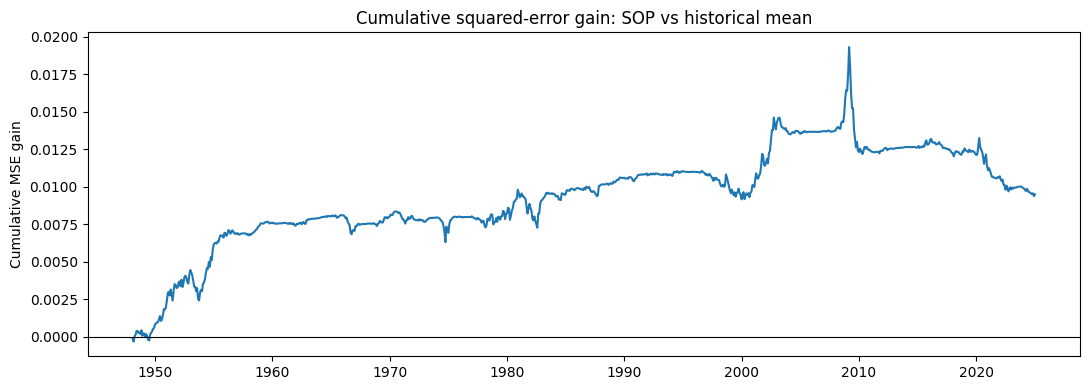

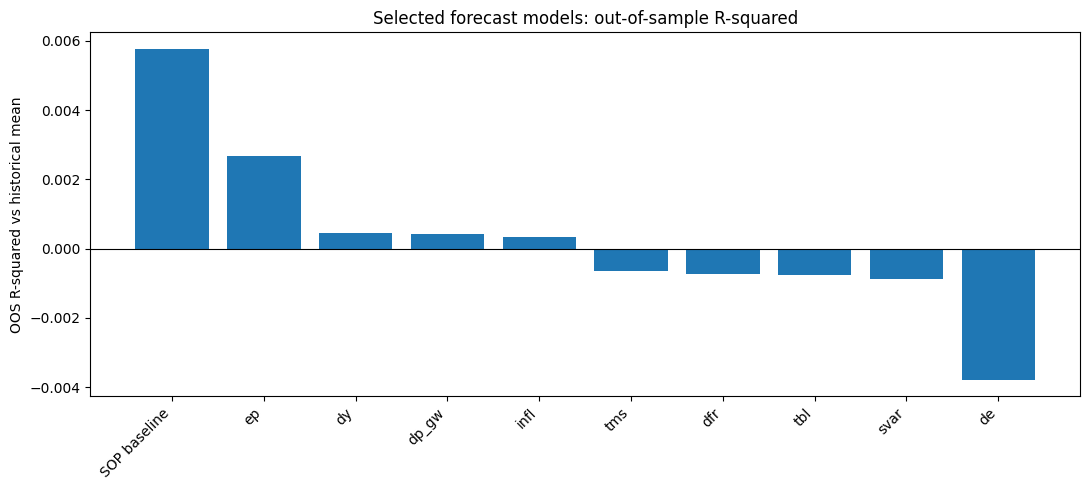

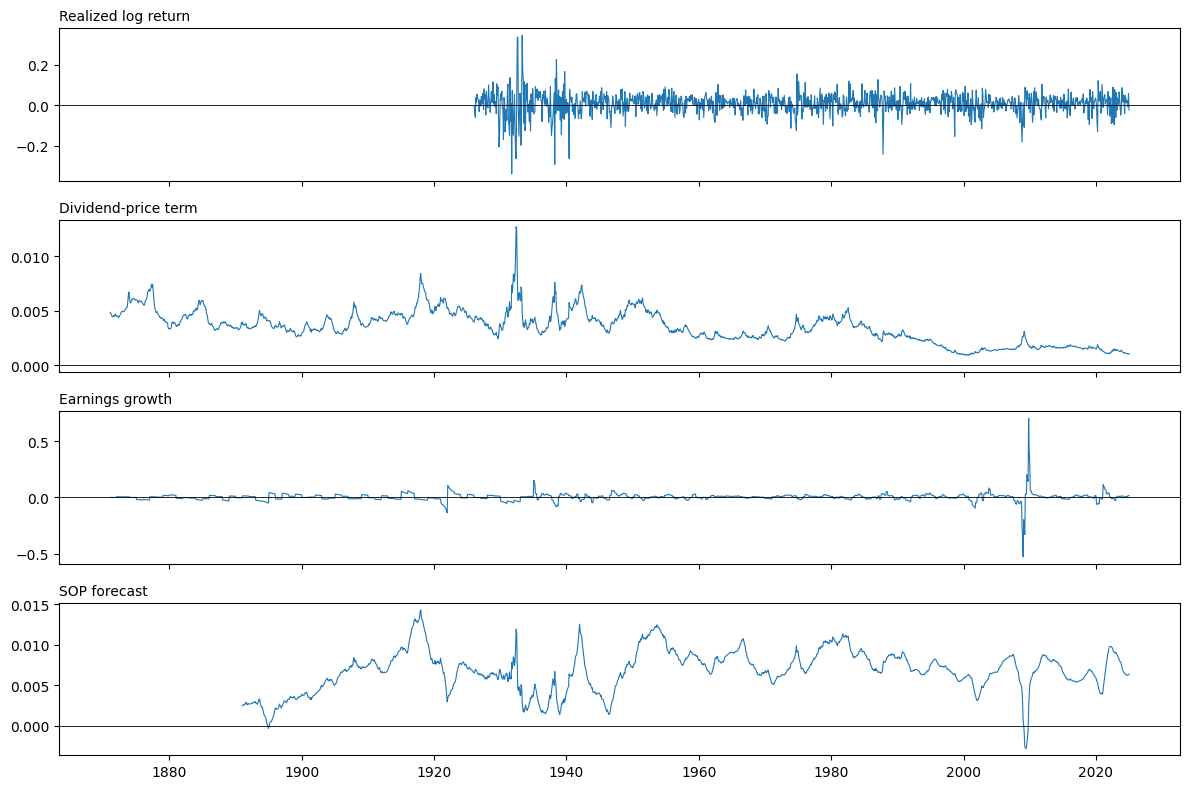

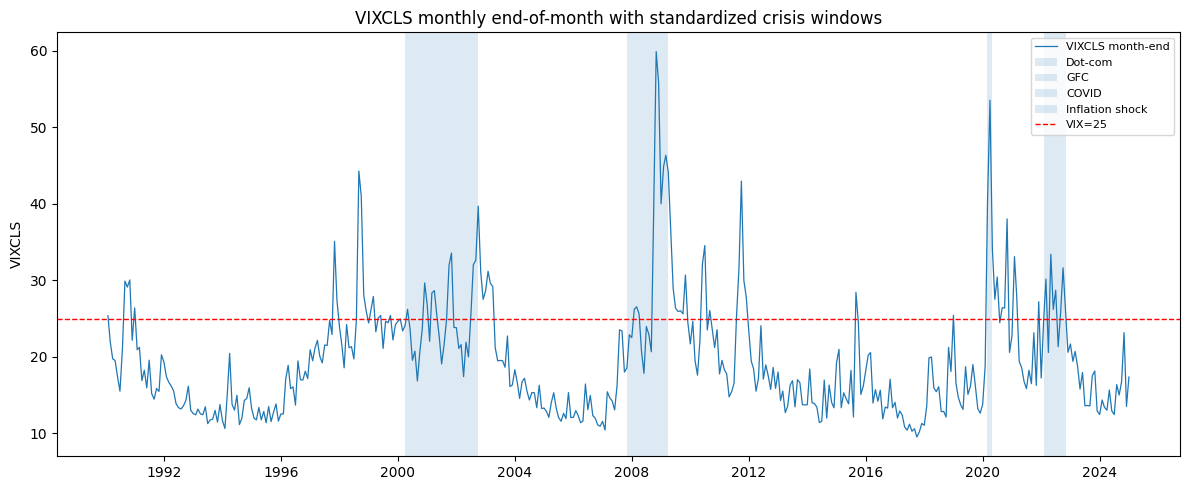

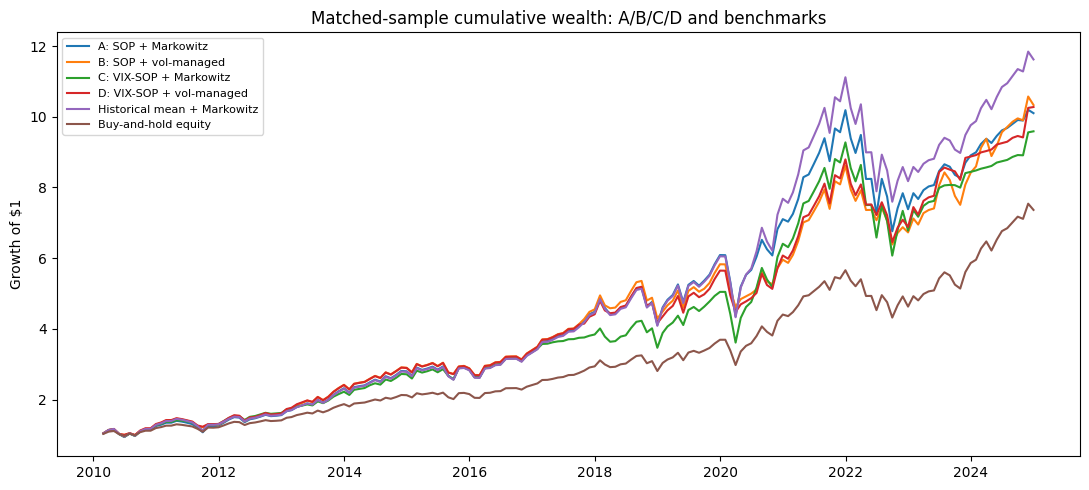

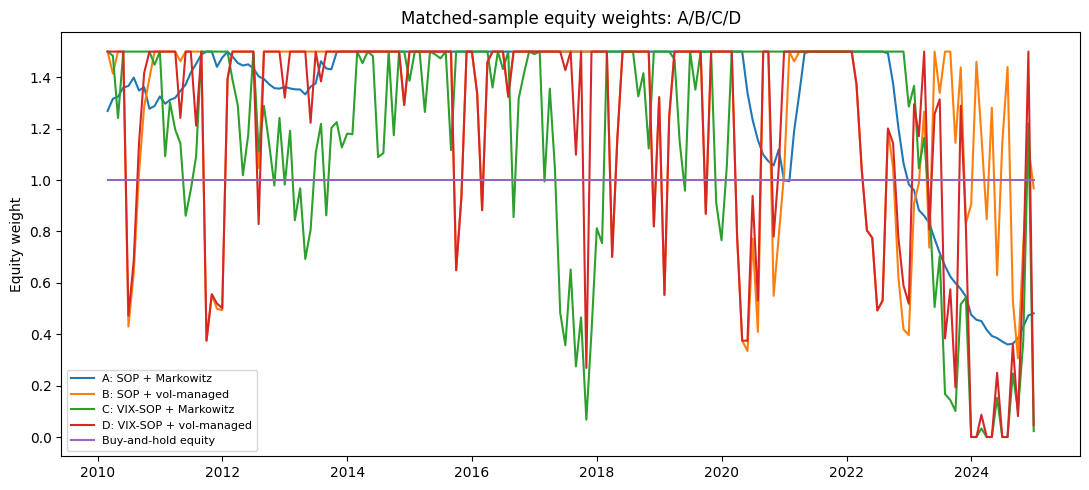

In [19]:
# ============================================================
# 18. Figures and last-12 forecast table
# ============================================================

last12_cols = ["date", "forecast_target_date", "ret_lead", "hist_mean", "ms", "ms_enh_VIXCLS", "ms_enh_dfy", "ms_enh_ntis", "ms_lagfund", "ms_winsor"]
last12 = vix_df.sort_values("date").tail(12)[[c for c in last12_cols if c in vix_df.columns]]
last12.to_csv(OUT / add_suffix("sop_last12_forecasts.csv"), index=False)
display(last12)

plot_data = eval_base.dropna(subset=["ret_lead", "ms", "hist_mean"]).copy()
plot_data["cum_mse_gain"] = ((plot_data["ret_lead"] - plot_data["hist_mean"]) ** 2 - (plot_data["ret_lead"] - plot_data["ms"]) ** 2).cumsum()
plt.figure(figsize=(11, 4))
plt.plot(plot_data["forecast_target_date"], plot_data["cum_mse_gain"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Cumulative squared-error gain: SOP vs historical mean")
plt.ylabel("Cumulative MSE gain")
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_cum_mse_gain.png"), dpi=200)
plt.show()

bar = bench_table.dropna(subset=["OOS_R2_vs_HM"]).copy()
bar = pd.concat([bar.head(5), bar.tail(5)]).drop_duplicates("model")
plt.figure(figsize=(11, 5))
plt.bar(bar["model"], bar["OOS_R2_vs_HM"])
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.title("Selected forecast models: out-of-sample R-squared")
plt.ylabel("OOS R-squared vs historical mean")
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_oos_r2_comparison.png"), dpi=200)
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, col, title in zip(axes, ["r_log", "dp", "ge", "ms"], ["Realized log return", "Dividend-price term", "Earnings growth", "SOP forecast"]):
    ax.plot(df["date"], df[col], linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(title, loc="left", fontsize=10)
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_sop_components.png"), dpi=200)
plt.show()

vix_plot = df.dropna(subset=["VIXCLS"]).copy()
if len(vix_plot):
    plt.figure(figsize=(12, 5))
    plt.plot(vix_plot["date"], vix_plot["VIXCLS"], linewidth=0.9, label="VIXCLS month-end")
    for name, (start, end) in CRISIS_WINDOWS.items():
        plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, label=name)
    plt.axhline(25, color="red", linestyle="--", linewidth=1, label="VIX=25")
    plt.title("VIXCLS monthly end-of-month with standardized crisis windows")
    plt.ylabel("VIXCLS")
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT / add_suffix("vix_crisis_chart.png"), dpi=200)
    plt.show()

plt.figure(figsize=(11, 5))
for label, (ret_col, _) in strategy_map.items():
    wealth = (1 + matched[ret_col]).cumprod()
    plt.plot(matched["forecast_target_date"], wealth, label=label)
plt.title("Matched-sample cumulative wealth: A/B/C/D and benchmarks")
plt.ylabel("Growth of $1")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_strategy_cum_wealth_matched.png"), dpi=200)
plt.show()

plt.figure(figsize=(11, 5))
for label, (_, weight_col) in strategy_map.items():
    if label.startswith(("A", "B", "C", "D")):
        plt.plot(matched["forecast_target_date"], matched[weight_col], label=label)
plt.title("Matched-sample equity weights: A/B/C/D")
plt.ylabel("Equity weight")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / add_suffix("fig_strategy_weights_matched.png"), dpi=200)
plt.show()

In [20]:
# ============================================================
# 19. End-to-end integrity checks
# ============================================================

required_exports = [
    "sop_monthly_enriched.csv",
    "sop_data_source_audit.csv",
    "sop_descriptive_stats.csv",
    "sop_baseline_forecast_performance.csv",
    "sop_annual_nonoverlap.csv",
    "sop_annual_forecast_performance.csv",
    "sop_benchmark_results.csv",
    "sop_vix_common_results.csv",
    "sop_vix_common_forecasts.csv",
    "sop_vix_dm_tests.csv",
    "sop_reversion_results.csv",
    "sop_crisis_forecast.csv",
    "sop_crisis_definition_overlap.csv",
    "sop_strategy_matched_results.csv",
    "sop_abcd_returns_matched.csv",
    "sop_crisis_portfolio_outcomes.csv",
    "sop_sharpe_tests_matched.csv",
    "sop_ceq_gain_matched.csv",
    "sop_robustness.csv",
    "sop_last12_forecasts.csv",
    "fig_cum_mse_gain.png",
    "fig_oos_r2_comparison.png",
    "fig_sop_components.png",
    "vix_crisis_chart.png",
    "fig_strategy_cum_wealth_matched.png",
    "fig_strategy_weights_matched.png",
]
required_exports = [OUT / add_suffix(x) for x in required_exports]
missing = [str(p) for p in required_exports if not p.exists()]

checks = {
    "hist_mean_full_panel_non_null": int(df["hist_mean"].notna().sum()),
    "vix_common_N": int(len(vix_common)),
    "matched_strategy_N": int(len(matched)),
    "missing_exports": len(missing),
    "strategy_sample_start": matched["forecast_target_date"].min(),
    "strategy_sample_end": matched["forecast_target_date"].max(),
}

print("Integrity checks:")
for k, v in checks.items():
    print(f"  {k}: {v}")

if missing:
    print("Missing exports:")
    for p in missing:
        print("  ", p)
    raise RuntimeError("Some expected exports are missing.")

print("All expected fixed outputs were generated.")

Integrity checks:
  hist_mean_full_panel_non_null: 949
  vix_common_N: 179
  matched_strategy_N: 179
  missing_exports: 0
  strategy_sample_start: 2010-02-28 00:00:00
  strategy_sample_end: 2024-12-31 00:00:00
All expected fixed outputs were generated.
